# 定義元素進行變異 - stock
表示法：定義每個策略元素為一個基因。  
初始群體生成：創建一個包含多個個體的初始群體，每個個體是一組隨機選擇的策略元素組合。  
適應度函數：設計一個適應度函數來評估每個個體的優良程度。可以根據一些具體指標（如市場反應、投資回報率等）來評估策略組合的優劣。  
選擇：根據適應度函數選擇一些優良個體進行交配和變異。  
交叉：對選擇的個體進行交叉操作，生成新的個體。  
變異：對一些個體進行變異操作，以引入多樣性。  
迭代：重複以上步驟多次，直到找到最優的策略組合。

In [1]:
import os
import textwrap
import math
import pandas as pd
import numpy as np

from datetime import datetime
from dateutil.relativedelta import relativedelta

import google.generativeai as genai
from langchain.schema.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

from IPython.display import display
from IPython.display import Markdown

model = 'gemini-1.5-flash'
temperature = 1
top_p = 0.9
seed = 0

def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
                
            })

# 定義策略元素字典，每個元素對應一個代號
elements = {
    "E1": "企業創新策略：企業創新的核心主題，涵蓋所有驅動企業增長和競爭力提升的策略。",
    "E2": "滿足客戶需求：企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。",
    "E3": "吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，是創新成功的重要標誌。",
    "E4": "市場需求與趨勢：市場需求的變化和行業趨勢是影響企業股票表現的關鍵因素，企業需適應並預測市場變化。",
    "E5": "財務表現：穩定且增長的收入、利潤和現金流是吸引投資者的主要因素，能增加投資者信心，推動股價上漲。",
    "E6": "技術進步與研發投入：持續的技術創新和研發投入能提高企業競爭力和市場地位，促進企業長期增長。",
    "E7": "經營效率：有效的經營管理能提高企業盈利能力，進而提升股票價值。",
    "E8": "品牌聲譽與市場認可度：良好的品牌聲譽和市場認可度能增加企業產品的市場需求，促進銷售增長。",
    "E9": "政策與法規支持：政府政策和法規對行業的支持或限制會直接影響企業的發展前景和市場表現。",
    "E10": "競爭優勢與市場份額：企業在市場中的競爭優勢和市場份額的提升能增強其市場地位，吸引更多投資者。",
    "E11": "全球化與國際市場拓展：進入國際市場並擴展全球業務能增加企業的市場規模和收入來源。",
    "E12": "風險管理與應對能力：有效的風險管理策略和應對能力能降低企業運營風險，提高投資者信心。",
    "E13": "人才管理與員工激勵：擁有高素質的人才和有效的激勵機制能提升企業創新能力和生產效率。",
    "E14": "合作夥伴關係：與其他企業建立戰略合作夥伴關係能共享資源和技術，提升市場競爭力。",
    "E15": "市場營銷與品牌推廣：有效的市場營銷和品牌推廣策略能提高企業知名度和市場需求。",
    "E16": "客戶服務與滿意度：高品質的客戶服務和較高的客戶滿意度能提高客戶忠誠度和口碑。",
    "E17": "供應鏈管理：高效的供應鏈管理能確保產品質量和交付效率，降低成本。",
    "E18": "產品多樣化與創新：不斷推出創新產品和服務能滿足不同市場需求，提升企業競爭力。",
    "E19": "環保與可持續發展：採用環保和可持續發展策略能提高企業形象，吸引關注可持續投資的投資者。",
    "E20": "數位轉型與科技應用：積極進行數位轉型和應用新技術能提高運營效率和市場響應速度。",
    "E21": "競爭對手分析與市場擴展：深入分析競爭對手的策略和行動，制定有效的市場擴展和新市場進入策略。",
    "E22": "資本結構、財務穩定性與資金籌措：健康的資本結構和財務穩定性以及有效的資金籌措能增強企業的抗風險能力和持續發展能力。",
    "E23": "客戶數據分析：利用大數據和數據分析技術深入了解客戶需求，提升產品和服務的針對性。",
    "E24": "知識產權保護：有效保護企業的知識產權能防止競爭對手抄襲，提高創新成果的市場價值。",
    "E25": "企業文化與價值觀：建立積極向上的企業文化和價值觀能吸引優秀人才，提升企業凝聚力和創新力。",
    "E26": "股東回報與分紅政策：穩定的股東回報和合理的分紅政策能吸引長期投資者。",
    "E27": "社會責任與公益活動：積極參與社會責任和公益活動能提升企業形象，獲得更多社會支持。",
    "E28": "成本控制: 有效的成本控制能提高企業獲利能力。",
}

# 檔案路徑設定
# folder_list = ['2330', '2454', '2317', '2382', '2308', '3711']
# stock_names =  ['台積電', '聯發科', '鴻海', '廣達', '台達電', '日月光']

id = '2330'
stock_name = "台積電"
path_price = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', id + 'tech.csv')
path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + id + "news_title.json"
path_out = "out_GA_Stock/"

c:\Users\user\Desktop\LLM-Predict-Stock\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 使用過的 Prompt

In [2]:
# 台積電的{tech_prompt}
# 以下是新聞標題：『{text_news}』
# 請一步一步的用上面的資訊思考台積電隔天開盤到收盤的可能漲跌，如果你認為台積電會上漲請回答#yes，如果你認為台積電會下跌請回答#no

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由


In [3]:
# 以下是台積電的新聞標題：『{text_news}』
# 請一步一步的用上面的資訊思考台積電隔天開盤到收盤的可能漲跌，如果你認為台積電會上漲請回答#yes，如果你認為台積電會下跌請回答#no

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由

# 主程式

In [4]:
# 透過前一天的新聞判斷今日的股市走勢
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def call_tech(d):
    
    # 讀取CSV檔案
    df = pd.read_csv(path_price, encoding='utf-8')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    df = df[(d == df['Date'])]

    # 計算5日均線
    ma5 = "上漲" if df['MA5'].values[0] < df["Close"].values[0] else "下跌"
    ma10 = "之上" if df['MA10'].values[0] < df["Close"].values[0] else "之下"
    ma20 = "之上" if df['MA20'].values[0] < df["Close"].values[0] else "之下"
    ema5 = "上漲" if df['EMA5'].values[0] < df["Close"].values[0] else "下跌"
    ema12 = "之上" if df['EMA12'].values[0] < df["Close"].values[0] else "之下"
    ema26 = "之上" if df['EMA26'].values[0] < df["Close"].values[0] else "之下"
    dif_macd = round(df['DIF'].values[0] - df['MACD'].values[0],3) 

    elements_tech = [
        # f"五日均線為{ma5}趨勢",
        # f"收盤後股價在5日均線{ma5},10日均線{ma10},20日均線{ma20}",
        # f"RSI值為{round(df['RSI'].values[0], 3)}",
        # f"MACD指標值, DIF-MACD值:{dif_macd}",
        # f"KD值為,k:{round(df['K'].values[0],1)},d:{round(df['D'].values[0], 1)}",
        # f'開盤{df["開盤指數"].values[0]}，最高{df["最高指數"].values[0]}，最低{df["Low"].values[0]}，收盤{df["Close"].values[0]}',
        # f"收盤後股價在12日加權平均線{ema12},26日加權平均線{ema26}",
        f"五日加權移動平均線為{ema5}趨勢",
    ]

    prompt_tech = ""
    for i in range(len(elements_tech)):
        prompt_tech += f"{str(i+1)} : {elements_tech[i]}\n"
    return prompt_tech

def analyze_market(st, et, prompt_element):
    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['Date']) & (df_price_his['Date'] <= et)]

    idx = 1
    batch_size = 200
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    while idx < len(df_price_his):
        batch = []
        for i in range(batch_size):
            if idx + i >= len(df_price_his):
                break
            
            # 取得前一日日期和新聞標題
            news_date = df_price_his.iloc[idx + i]['Date'] - timedelta(days=1)
            prompt_news = ""
            with open(path_news_title, 'r', encoding='utf-8') as f:
                news_data = json.load(f)
                prompt_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
            
            # 取得前一個交易日的技術指標
            last_date = df_price_his.iloc[idx + i - 1]['Date']
            prompt_tech = call_tech(last_date)
            # 當日股價的技術指標如下： 『{tech_prompt}』
            # {stock_name}的{tech_prompt}

            # 建立prompt
            messages = [
                ("system", "你是一個厲害的股市操盤手，專長是當日沖消"),
                ("human",
f"""
以下是{stock_name}的新聞標題：
『{prompt_news}』

如果有滿足以下的條件，則請只回答#yes 否則只回答#no
{prompt_element}

用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
判斷結果: #yes/#no
你的理由: 說明你的判斷理由
""")
            ]
            batch.append(messages)

        res = llm.batch(batch)

        for i in range(len(res)):
            # 被預測的日期
            date_str = df_price_his.iloc[idx + i]['Date'].strftime('%Y%m%d')
            output_data[date_str] = {
                "token": res[i].usage_metadata,
                "raw_data": res[i].content,
            }

        # time.sleep(60)
        idx += batch_size

    # 將所有輸出數據寫入字典中
    data = {
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "output_data": output_data,
    }
    
    return data

In [5]:
def save_data(folder_path, data):
    # count = 1
    # while True:
    #     if os.path.exists(folder_path + str(count) + ".json"):
    #         count += 1
    #         continue
    #     else:
    #         out_file = folder_path + str(count) + ".json"
    #         break
    out_file = folder_path + ".json"
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    
    return out_file

## 評分

In [6]:
import pandas as pd
import json
import os

def eval(output_data):
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    token_input = 0
    token_output = 0

    df_price_his = pd.read_csv(path_price, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')

    for date_str, result in output_data.items():
        token_input += result["token"]["input_tokens"]
        token_output += result["token"]["output_tokens"]
        sig_str = result["raw_data"].split("你的理由")[0]
        sig = 0

        if "unknown" in sig_str:
            sig = 0
        elif "yes" in sig_str:
            sig = 1
        elif "no" in sig_str:
            sig = -1
        else:
            sig = 0

        df_price = df_price_his[df_price_his['Date'] == pd.to_datetime(date_str, format='%Y%m%d')]

        if df_price.empty:
            continue

        rtn = (df_price.iloc[0]['Close'] - df_price.iloc[0]['Open']) / df_price.iloc[0]['Open']

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
        'ask_count': len(output_data),
        'token_input': token_input,
        'token_output': token_output,
    }

    return result

# Testing

In [8]:
start_day = datetime(2023, 7, 1)
end_day = datetime(2024, 6, 30)

individual = ["E12", "E28", "E7", "E24"] # 這裡填入訓練出的最佳元素
prompt = ""
for i in range(len(individual)):
    prompt += f"{str(i+1)} : {elements[individual[i]]}\n"

dic_data = analyze_market(start_day, end_day, prompt)
save_data(path_out + id + "news_yn", dic_data)

# 輸出結果
result = eval(dic_data["output_data"])
print(f"time period: {start_day} ~ {end_day}")
print(f'''
tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
precision : {round(result["precision"],5)}, precision_ev : {round(result["precision_ev"], 7)},
recall : {round(result["recall"],5)}''')  

time period: 2023-07-01 00:00:00 ~ 2024-06-30 00:00:00

tp : 106, fp : 116, tn : 3, fn : 1, ask_count : 242
accuracy : 0.482, ev : 0.0005359,
precision : 0.47748, precision_ev : 0.0004035,
recall : 0.99065


# DEMO

## 結果整理

In [62]:
import json

print(f"2023/07/1～2024/6/30")

stock_ids = ['2330', '2454', '2317', '2382', '2308', '3711']
stock_names = ['台積電', '聯發科', '鴻海', '廣達', '台達電', '日月光']

for i in range(len(stock_ids)):
    print(f"stock id: {stock_ids[i]}, stock name: {stock_names[i]}")
    with open(path_out + stock_ids[i] + "news.json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]
        result = eval(output_data)
        
        print("只有新聞")
        print(f'''tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
    accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
    precision : {round(result["precision"],3)}, precision_ev : {round(result["precision_ev"], 7)},
    ''')  

        print("新聞當prompt + 技術指標")
        result2 = eval2(output_data)
        print(f'''tp : {result2["tp"]}, fp : {result2["fp"]}, tn : {result2["tn"]}, fn : {result2["fn"]}, ask_count : {result2["ask_count"]}
    accuracy : {round(result2["accuracy"],3) }, ev : {round(result2["ev"], 7)},
    precision : {round(result2["precision"],3)}, precision_ev : {round(result2["precision_ev"], 7)},
    ''')
    
    print("新聞+技術指標同時當prompt")
    with open(path_out + stock_ids[i] +"newstech.json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]
        result = eval(output_data)
        print(f'''tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
    accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
    precision : {round(result["precision"],3)}, precision_ev : {round(result["precision_ev"], 7)},
    ''')  
        
    print("新聞+技術指標同時當prompt 判斷yes no unknown")
    with open(path_out + stock_ids[i] +"newstech_ynu.json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]
        result = eval(output_data)
        print(f'''tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
    accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
    precision : {round(result["precision"],3)}, precision_ev : {round(result["precision_ev"], 7)},
    ''')  
        
    print("新聞當prompt 判斷yes no unknown")
    with open(path_out + stock_ids[i] +"news_ynu.json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]
        result = eval(output_data)
        print(f'''tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
    accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
    precision : {round(result["precision"],3)}, precision_ev : {round(result["precision_ev"], 7)},
    ''')  
    
    print("=====================================")


2023/07/1～2024/6/30
stock id: 2330, stock name: 台積電
只有新聞
tp : 95, fp : 93, tn : 29, fn : 19, ask_count : 242
    accuracy : 0.525, ev : 0.0017848,
    precision : 0.505, precision_ev : 0.0012604,
    
新聞當prompt + 技術指標
tp : 50, fp : 44, tn : 14, fn : 17, ask_count : 242
    accuracy : 0.512, ev : -0.0001932,
    precision : 0.532, precision_ev : 0.0003506,
    
新聞+技術指標同時當prompt
tp : 83, fp : 86, tn : 32, fn : 30, ask_count : 242
    accuracy : 0.498, ev : 0.0006593,
    precision : 0.491, precision_ev : 0.0003937,
    
新聞+技術指標同時當prompt 判斷yes no unknown
tp : 45, fp : 39, tn : 2, fn : 1, ask_count : 242
    accuracy : 0.54, ev : 0.0018044,
    precision : 0.536, precision_ev : 0.0016741,
    
新聞當prompt 判斷yes no unknown
tp : 36, fp : 41, tn : 1, fn : 0, ask_count : 242
    accuracy : 0.474, ev : 0.0016373,
    precision : 0.468, precision_ev : 0.0014934,
    
stock id: 2454, stock name: 聯發科
只有新聞
tp : 78, fp : 85, tn : 22, fn : 15, ask_count : 200
    accuracy : 0.5, ev : 0.000444,
    prec

## 作圖

stock id: 2330, stock name: 台積電
stock id: 2454, stock name: 聯發科
stock id: 2317, stock name: 鴻海
stock id: 2382, stock name: 廣達
stock id: 2308, stock name: 台達電
stock id: 3711, stock name: 日月光


C:\Users\user\AppData\Local\Temp\ipykernel_3056\2549811896.py:84: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3056\2549811896.py:84: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3056\2549811896.py:84: UserWarning: Glyph 38651 (\N{CJK UNIFIED IDEOGRAPH-96FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3056\2549811896.py:84: UserWarning: Glyph 32879 (\N{CJK UNIFIED IDEOGRAPH-806F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3056\2549811896.py:84: UserWarning: Glyph 30332 (\N{CJK UNIFIED IDEOGRAPH-767C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3056\2549811896.py:84: UserWarning: Glyph 31185 (\N{CJK UNIFIE

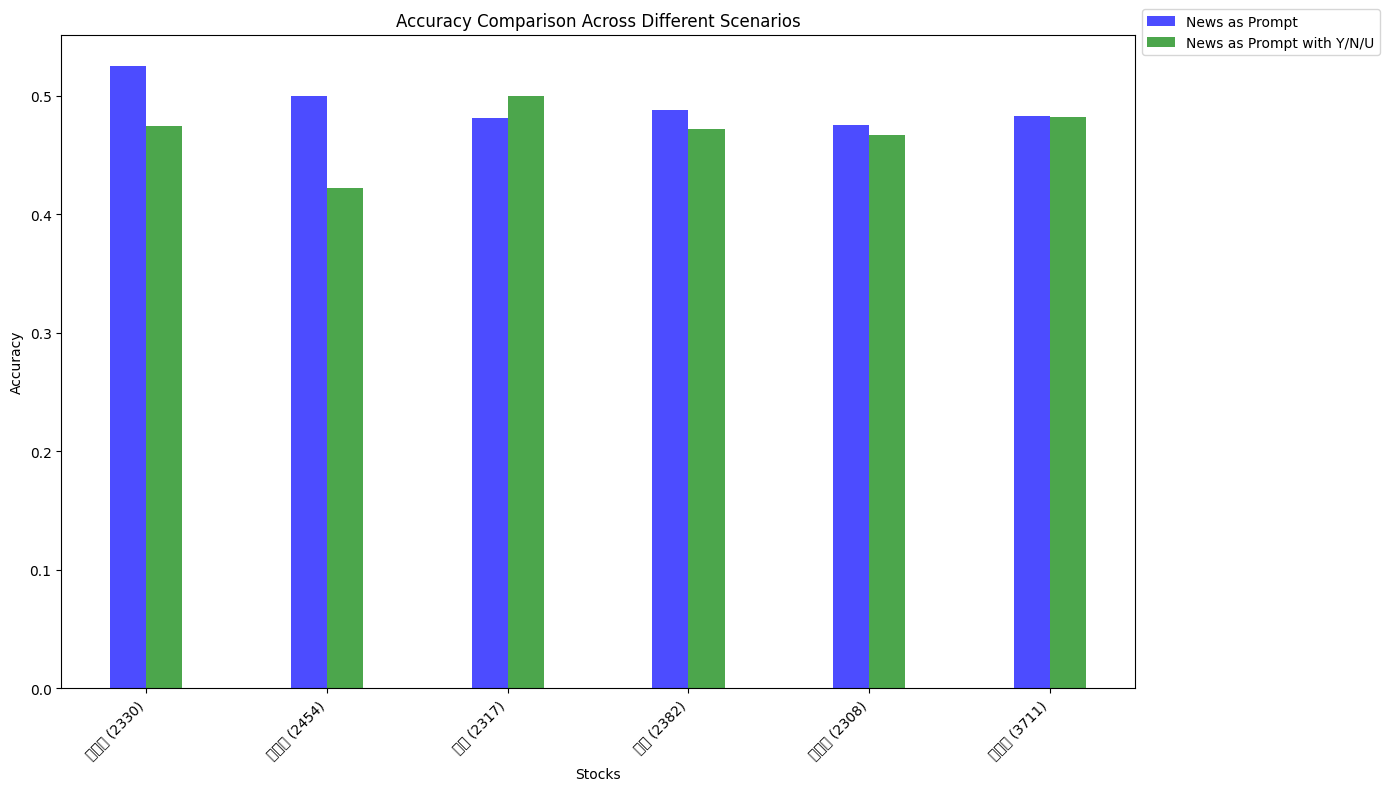

In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np

stock_ids = ['2330', '2454', '2317', '2382', '2308', '3711']
stock_names = ['台積電', '聯發科', '鴻海', '廣達', '台達電', '日月光']

# 儲存各個情境的準確度
accuracies = {
    'News as Prompt': [],
    # 'News as Prompt + Technical Indicators': [],
    # 'News and Technical Indicators as Prompt': [],
    'News as Prompt with Y/N/U': [],
    # 'News as Prompt with Y/N/U + Technical Indicators': [],
    # 'News and Technical Indicators as Prompt with Y/N/U': [],
}

# 讀取數據並計算準確度
for i in range(len(stock_ids)):
    print(f"stock id: {stock_ids[i]}, stock name: {stock_names[i]}")

    # 只有新聞
    with open(path_out + stock_ids[i] + "news.json", "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]
        result = eval(output_data)
        accuracies['News as Prompt'].append(round(result["accuracy"], 3))
    
    # # 新聞當prompt + 技術指標
    # result2 = eval2(output_data)  # 確保 eval2 函數的定義正確
    # accuracies['News as Prompt + Technical Indicators'].append(round(result2["accuracy"], 3))
    
    # # 新聞跟技術指標同時當prompt
    # with open(path_out + stock_ids[i] + "newstech.json", "r", encoding='utf-8') as f:
    #     data = json.load(f)
    #     output_data = data["output_data"]
    #     result = eval(output_data)
    #     accuracies['News and Technical Indicators as Prompt'].append(round(result["accuracy"], 3))
    
    # 新聞當prompt 判斷yes no unknown
    with open(path_out + stock_ids[i] + "news_ynu.json", "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]
        result = eval(output_data)
        accuracies['News as Prompt with Y/N/U'].append(round(result["accuracy"], 3))

    # # 新聞當prompt判斷yes no unknown + 技術指標
    # result2 = eval2(output_data)  # 確保 eval2 函數的定義正確
    # accuracies['News as Prompt with Y/N/U + Technical Indicators'].append(round(result2["accuracy"], 3))

    # # 新聞+技術指標同時當prompt 判斷yes no unknown
    # with open(path_out + stock_ids[i] + "newstech_ynu.json", "r", encoding='utf-8') as f:
    #     data = json.load(f)
    #     output_data = data["output_data"]
    #     result = eval(output_data)
    #     print(result)
    #     accuracies['News and Technical Indicators as Prompt with Y/N/U'].append(round(result["accuracy"], 3))
    print("=====================================")

# 畫出柱狀圖
fig, ax = plt.subplots(figsize=(14, 8))

bar_width = 0.2
index = np.arange(len(stock_ids))  # 股票的數量

# 設定每個情境的顏色
colors = ['b', 'g', 'r', 'c', 'm', 'y']

# 繪製每個情境的柱狀圖
for i, (scenario, color) in enumerate(zip(accuracies.keys(), colors)):
    bar_positions = index + i * bar_width
    ax.bar(bar_positions, accuracies[scenario], bar_width, label=scenario, color=color, alpha=0.7)

# 設定圖形
ax.set_xlabel('Stocks')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison Across Different Scenarios')
ax.set_xticks(index + (len(accuracies) - 1) * bar_width / 2)
ax.set_xticklabels([f'{stock_name} ({stock_id})' for stock_name, stock_id in zip(stock_names, stock_ids)], rotation=45, ha='right')

# 設定圖例位置
ax.legend(loc='upper left', bbox_to_anchor=(1, 1.05))

plt.tight_layout()
plt.show()


## 計算使用的費用

In [61]:
import json

input_token = 0
output_token = 0
for i in range(348):
    with open(f"out_element/0701_0331/{i+1}.json", 'r', encoding = 'utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]

        for date_str, result in output_data.items():
            input_token += result["token"]["input_tokens"]
            output_token += result["token"]["output_tokens"]
        # print(input_token, output_token)
    break

print(f'token: input {input_token}, output {output_token}')
print(f'預估費用 {(input_token/1000000)*0.35 + (output_token/1000000)*0.7} USD, {((input_token/1000000)*0.35 + (output_token/1000000)*0.7)*32.6} TWD')

token: input 69700, output 12422
預估費用 0.0330904 USD, 1.07874704 TWD
